In [1]:
import mujoco, mujoco.viewer
import mediapy as media
import time
import numpy as np

In [2]:
model = mujoco.MjModel.from_xml_path(r"D:\Files\Scripts\py\Graduation Project\external\mujoco_menagerie\unitree_a1\scene.xml")
data = mujoco.MjData(model)

dt = float(model.opt.timestep)

Image

""

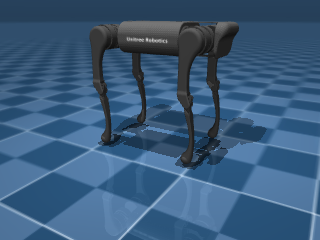

In [4]:
with mujoco.Renderer(model) as renderer:
	mujoco.mj_forward(model, data)
	renderer.update_scene(data)
	
	media.show_image(renderer.render())

Video

In [5]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
    #   print(data.time)
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


Live Render

In [6]:
with mujoco.viewer.launch_passive(model, data) as viewer:
	while viewer.is_running():
		mujoco.mj_step(model, data)
		viewer.sync()
		time.sleep(1/500)

Control Test

In [7]:
model.actuator_ctrlrange

array([[-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298],
       [-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298],
       [-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298],
       [-0.802851,  0.802851],
       [-1.0472  ,  4.18879 ],
       [-2.69653 , -0.916298]])

In [8]:
data.ctrl

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [9]:
data.time

19.208000000000233

In [10]:
duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)  # Reset state and time.
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    for i in range(len(data.ctrl)):
        magnitude = model.actuator_ctrlrange[i, 1] - model.actuator_ctrlrange[i, 0]
        median = 0.5 * (model.actuator_ctrlrange[i, 0] + model.actuator_ctrlrange[i, 1])
        data.ctrl[i] = median + 0.5 * magnitude * np.sin(2 * np.pi * data.time + i*np.pi/4)
        
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


PPO Training

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from env import UnitreeA1Env

xmlPath = r"D:\Files\Scripts\py\Graduation Project\external\mujoco_menagerie\unitree_a1\scene.xml"

In [25]:
# Train live view

env = UnitreeA1Env(xmlPath, render_mode="human")
model = PPO("MlpPolicy", env, verbose=1)

obs, _ = env.reset()
episode_reward = 0
episode_rewards = []

for step in range(50_000):
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    env.render()
    episode_reward += reward

    if terminated or truncated:
        episode_rewards.append(episode_reward)
        episode_reward = 0
        obs, _ = env.reset()

        # Print every 10 episodes
        if len(episode_rewards) % 10 == 0:
            mean = sum(episode_rewards[-10:]) / 10
            print(f"Episode {len(episode_rewards)} | Mean reward (last 10): {mean:.2f}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Episode 10 | Mean reward (last 10): 16.50
Episode 20 | Mean reward (last 10): 57.65
Episode 30 | Mean reward (last 10): 60.50
Episode 40 | Mean reward (last 10): 18.91
Episode 50 | Mean reward (last 10): 28.00
Episode 60 | Mean reward (last 10): 64.59
Episode 70 | Mean reward (last 10): 30.91
Episode 80 | Mean reward (last 10): 41.43
Episode 90 | Mean reward (last 10): 65.95
Episode 100 | Mean reward (last 10): 66.46
Episode 110 | Mean reward (last 10): 64.37
Episode 120 | Mean reward (last 10): 69.41
Episode 130 | Mean reward (last 10): 32.05
Episode 140 | Mean reward (last 10): 26.46
Episode 150 | Mean reward (last 10): 49.11
Episode 160 | Mean reward (last 10): 68.68
Episode 170 | Mean reward (last 10): 75.07
Episode 180 | Mean reward (last 10): 16.30
Episode 190 | Mean reward (last 10): 47.01
Episode 200 | Mean reward (last 10): 75.76
Episode 210 | Mean reward (last 10): 69.13


In [26]:
# Headless training

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

xml = r"D:\Files\Scripts\py\Graduation Project\external\mujoco_menagerie\unitree_a1\scene.xml"

class LogCallback(BaseCallback):
    def _on_step(self):
        if len(self.model.ep_info_buffer) > 0 and self.n_calls % 10_000 == 0:
            mean_reward = np.mean([e["r"] for e in self.model.ep_info_buffer])
            mean_len    = np.mean([e["l"] for e in self.model.ep_info_buffer])
            print(f"steps={self.num_timesteps:>8} | mean_ep_reward={mean_reward:>8.2f} | mean_ep_len={mean_len:>6.0f}")
        return True

env = make_vec_env(lambda: UnitreeA1Env(xml), n_envs=4)

model = PPO(
    "MlpPolicy",
    env,
    n_steps=2048,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,       # small entropy bonus helps exploration
    learning_rate=3e-4,
    verbose=0,           # silence SB3's own output, use our callback instead
    tensorboard_log="./tb_logs/",
)

model.learn(total_timesteps=5_000_000, callback=LogCallback())
model.save("a1_walk_v1")

steps=   40000 | mean_ep_reward=   66.01 | mean_ep_len=   250
steps=   80000 | mean_ep_reward=  142.86 | mean_ep_len=   262
steps=  120000 | mean_ep_reward=  161.48 | mean_ep_len=   222
steps=  160000 | mean_ep_reward=  218.52 | mean_ep_len=   233
steps=  200000 | mean_ep_reward=  280.58 | mean_ep_len=   244
steps=  240000 | mean_ep_reward=  310.65 | mean_ep_len=   252
steps=  280000 | mean_ep_reward=  316.48 | mean_ep_len=   245
steps=  320000 | mean_ep_reward=  361.54 | mean_ep_len=   280
steps=  360000 | mean_ep_reward=  398.41 | mean_ep_len=   297
steps=  400000 | mean_ep_reward=  431.21 | mean_ep_len=   320
steps=  440000 | mean_ep_reward=  515.67 | mean_ep_len=   366
steps=  480000 | mean_ep_reward=  537.17 | mean_ep_len=   393
steps=  520000 | mean_ep_reward=  609.80 | mean_ep_len=   465
steps=  560000 | mean_ep_reward=  682.10 | mean_ep_len=   515
steps=  600000 | mean_ep_reward=  837.10 | mean_ep_len=   599
steps=  640000 | mean_ep_reward=  907.74 | mean_ep_len=   626
steps=  

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os

def plot_training_logs(log_dir: str, output_path: str = "training_progress.png"):
    # Load the tensorboard event file
    acc = EventAccumulator(log_dir)
    acc.Reload()

    print("Available tags:", acc.Tags()["scalars"])

    # Define which metrics to plot and their display names
    metrics = {
        "rollout/ep_rew_mean":   "Mean Episode Reward",
        "rollout/ep_len_mean":   "Mean Episode Length",
        "train/policy_loss":     "Policy Loss",
        "train/value_loss":      "Value Loss",
        "train/entropy_loss":    "Entropy Loss",
        "train/approx_kl":       "Approx KL Divergence",
        "train/clip_fraction":   "Clip Fraction",
        "train/explained_variance": "Explained Variance",
    }

    # Filter to only metrics that exist in the log
    available = {k: v for k, v in metrics.items() if k in acc.Tags()["scalars"]}

    n = len(available)
    cols = 2
    rows = (n + 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
    fig.suptitle("PPO Training Progress — Unitree A1", fontsize=14, fontweight="bold", y=1.01)
    axes = axes.flatten()

    for i, (tag, title) in enumerate(available.items()):
        events = acc.Scalars(tag)
        steps  = [e.step  for e in events]
        values = [e.value for e in events]

        ax = axes[i]
        ax.plot(steps, values, linewidth=1.2, color="#5B6AD0")

        # Smooth trendline (rolling average)
        if len(values) > 20:
            window = max(1, len(values) // 20)
            smoothed = np.convolve(values, np.ones(window)/window, mode="valid")
            smooth_steps = steps[window-1:]
            ax.plot(smooth_steps, smoothed, linewidth=2, color="#E8593C", label="smoothed")
            ax.legend(fontsize=9)

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Timesteps", fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved to {output_path}")


# Point this at your tensorboard log folder
# It's usually ./tb_logs/PPO_1/ — check what folder was created
log_dir = r".\tb_logs\PPO_1"
plot_training_logs(log_dir, output_path="a1_progress_5m_steps.png")

Available tags: ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss']
Saved to a1_progress_5m_steps.png


Load a model

In [27]:
from stable_baselines3 import PPO
import numpy as np

# Load the trained model
model = PPO.load("a1_walk_v1")

# Create a render env
env = UnitreeA1Env(xml, render_mode="human")
obs, _ = env.reset()

while True:
    action, _ = model.predict(obs, deterministic=True)  # deterministic=True = no random sampling
    obs, reward, terminated, truncated, _ = env.step(action)
    env.render()
    if terminated or truncated:
        obs, _ = env.reset()

KeyboardInterrupt: 

export a 10 second video at 60 FPS of the model

In [4]:
from record_video import record_video
record_video(
    model_path="a1_walk_v1",
	env=UnitreeA1Env,
    xml_path=r"D:\Files\Scripts\py\Graduation Project\external\mujoco_menagerie\unitree_a1\scene.xml",
    output_path="a1_progress_5m_steps.mp4",
    duration_seconds=10,
    fps=60
)

Saved 10s video (600 frames) to a1_progress_5m_steps.mp4
